In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import shap, pickle, os, sys, warnings
sys.path.insert(0, os.getcwd())
from utils import evaluate_model
warnings.filterwarnings('ignore')
os.makedirs('models',  exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('plots',   exist_ok=True)

df = pd.read_csv('data/tea_demand_processed.csv', parse_dates=['week_start_date'])
print(f"Loaded processed dataset: {df.shape}")

Loaded processed dataset: (780, 39)


In [2]:
# All grade dummy columns
grade_cols = [c for c in df.columns if c.startswith('grade_')]

FEATURE_COLS = (
    grade_cols +
    ['colombo_auction_price_lkr', 'price_lag1w', 'price_rollmean4w',
     'usd_lkr_rate', 'rainfall_index', 'festival_flag',
     'demand_lag1w', 'demand_lag2w', 'demand_lag4w', 'demand_lag8w',
     'demand_lag13w', 'demand_lag26w', 'demand_lag52w',
     'demand_rollmean4w', 'demand_rollmean12w', 'demand_rollmean26w',
     'demand_rollstd4w', 'demand_rollstd12w',
     'week_sin', 'week_cos', 'month_sin', 'month_cos', 'quarter']
)

# Only keep columns that actually exist
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
TARGET = 'demand_kg'

train = df[df['year'] <  2024]
test  = df[df['year'] >= 2024]

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET]

print(f"Features : {len(FEATURE_COLS)}")
print(f"Train    : {len(X_train)} rows")
print(f"Test     : {len(X_test)} rows")

Features : 26
Train    : 520 rows
Test     : 260 rows


In [3]:
print("Training XGBoost with 5-fold TimeSeriesSplit CV...")

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

xgb_model = XGBRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=6, subsample=0.8,
    colsample_bytree=0.8, random_state=42,
    early_stopping_rounds=30, eval_metric='rmse', verbosity=0
)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr,  y_tr  = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    fold_mae = mean_absolute_error(y_val, xgb_model.predict(X_val))
    cv_scores.append(fold_mae)
    print(f"  Fold {fold+1} MAE: {fold_mae:,.0f} kg")

print(f"\nCV Mean MAE : {np.mean(cv_scores):,.0f} ± {np.std(cv_scores):,.0f} kg")

# Final fit on full training set
xgb_model.set_params(early_stopping_rounds=None)
xgb_model.fit(X_train, y_train, verbose=False)
xgb_pred    = xgb_model.predict(X_test)
xgb_metrics = evaluate_model('XGBoost', y_test.values, xgb_pred)

pickle.dump(xgb_model, open('models/xgb_model.pkl', 'wb'))
print("Model saved → models/xgb_model.pkl")

Training XGBoost with 5-fold TimeSeriesSplit CV...
  Fold 1 MAE: 692 kg
  Fold 2 MAE: 1,443 kg
  Fold 3 MAE: 1,008 kg
  Fold 4 MAE: 383 kg
  Fold 5 MAE: 270 kg

CV Mean MAE : 759 ± 428 kg

  Model: XGBoost
  MAE   : 466.54 kg
  RMSE  : 729.79 kg
  MAPE  : 10.91%
  sMAPE : 11.17%
Model saved → models/xgb_model.pkl


In [4]:
print("Training LightGBM...")

lgbm_model = LGBMRegressor(
    n_estimators=500, learning_rate=0.05,
    num_leaves=63, subsample=0.8,
    colsample_bytree=0.8, random_state=42, verbose=-1
)
lgbm_model.fit(X_train, y_train)
lgbm_pred    = lgbm_model.predict(X_test)
lgbm_metrics = evaluate_model('LightGBM', y_test.values, lgbm_pred)

pickle.dump(lgbm_model, open('models/lgbm_model.pkl', 'wb'))
print("Model saved → models/lgbm_model.pkl")

Training LightGBM...

  Model: LightGBM
  MAE   : 486.30 kg
  RMSE  : 715.38 kg
  MAPE  : 11.67%
  sMAPE : 11.88%
Model saved → models/lgbm_model.pkl


Generating XGBoost feature importance...


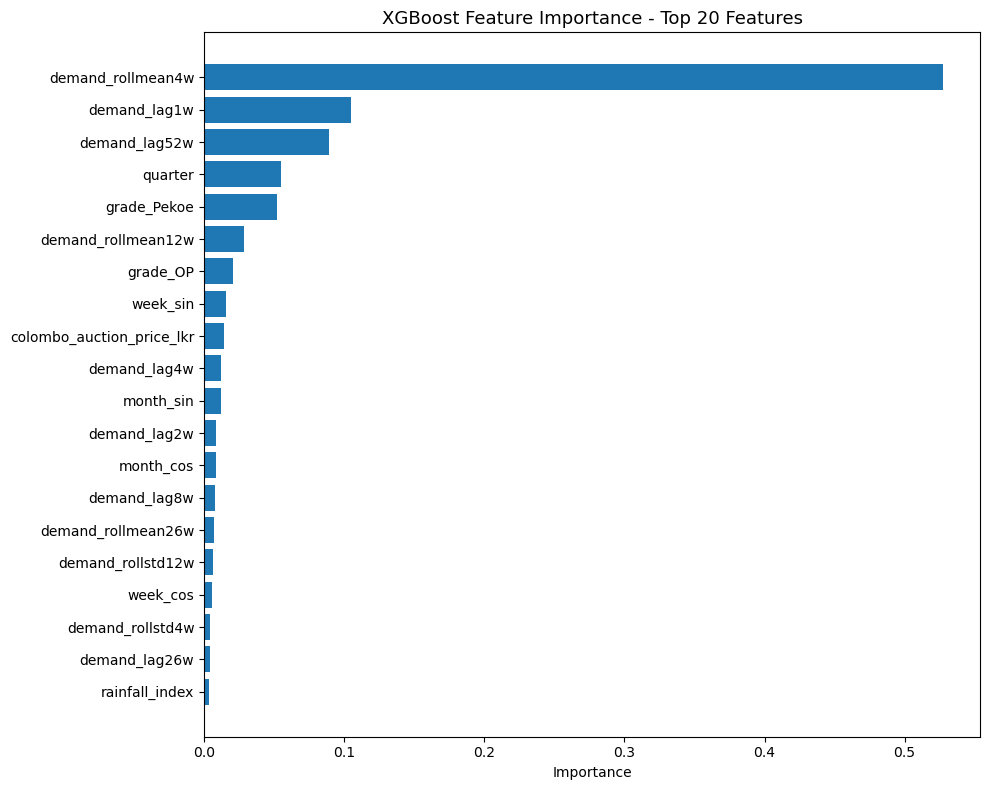

Saved → plots/xgb_feature_importance.png


,Feature,Importance
16,demand_rollmean4w,0.527436
9,demand_lag1w,0.104589
15,demand_lag52w,0.088901
25,quarter,0.054579
4,grade_Pekoe,0.052148
17,demand_rollmean12w,0.028662
3,grade_OP,0.020976
21,week_sin,0.015919
5,colombo_auction_price_lkr,0.014474
11,demand_lag4w,0.012156


In [6]:
print("Generating XGBoost feature importance...")

importance = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance_df["Feature"].head(20),
    feature_importance_df["Importance"].head(20)
)
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance - Top 20 Features", fontsize=13)
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("plots/xgb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved → plots/xgb_feature_importance.png")
feature_importance_df.head(20)

In [7]:
ml_results = pd.DataFrame([xgb_metrics, lgbm_metrics])
ml_results.to_csv("results/ml_results.csv", index=False)

print("Saved → results/ml_results.csv")
ml_results

Saved → results/ml_results.csv


,model,MAE,RMSE,MAPE,sMAPE
0,XGBoost,466.54,729.79,10.91,11.17
1,LightGBM,486.30,715.38,11.67,11.88


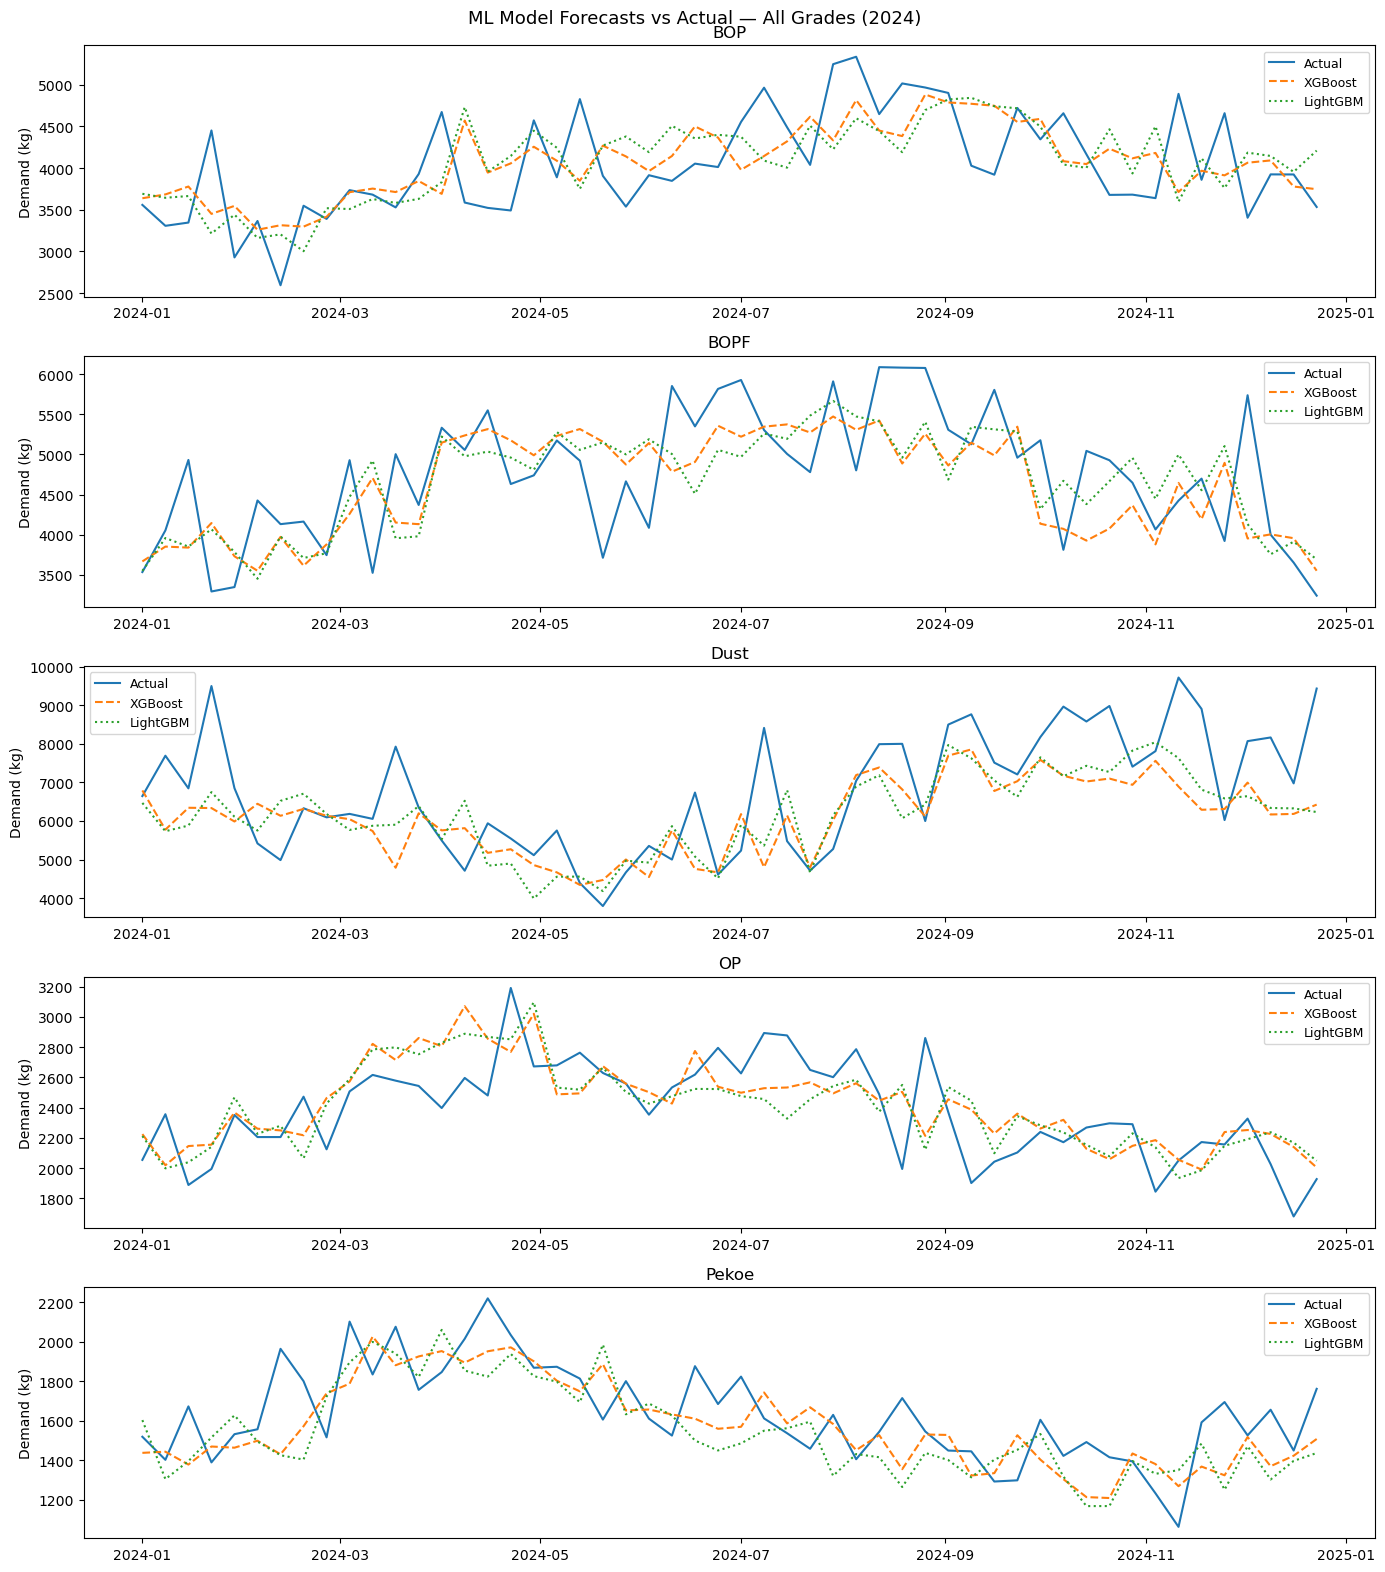

Saved → results/ml_results.csv


In [8]:
grades_raw = df['week_start_date'].apply(lambda x: x).copy()  # dummy
grade_cols_list = [c.replace('grade_', '') for c in df.columns if c.startswith('grade_')]

fig, axes = plt.subplots(len(grade_cols_list), 1, figsize=(14, 16))

for ax, grade in zip(axes, grade_cols_list):
    mask = test[f'grade_{grade}'] == 1
    ax.plot(test.loc[mask, 'week_start_date'], y_test[mask],
            label='Actual', linewidth=1.5)
    ax.plot(test.loc[mask, 'week_start_date'], xgb_pred[mask.values],
            label='XGBoost', linewidth=1.5, linestyle='--')
    ax.plot(test.loc[mask, 'week_start_date'], lgbm_pred[mask.values],
            label='LightGBM', linewidth=1.5, linestyle=':')
    ax.set_title(grade)
    ax.set_ylabel('Demand (kg)')
    ax.legend(fontsize=9)

plt.suptitle('ML Model Forecasts vs Actual — All Grades (2024)', fontsize=13)
plt.tight_layout()
plt.savefig('plots/ml_forecast_all_grades.png', dpi=150)
plt.show()

# Save ML results
ml_df = pd.DataFrame([xgb_metrics, lgbm_metrics])
ml_df.to_csv('results/ml_results.csv', index=False)
print("Saved → results/ml_results.csv")

In [9]:
import numpy as np
np.save('results/xgb_pred.npy',  xgb_pred)
np.save('results/lgbm_pred.npy', lgbm_pred)
np.save('results/y_test.npy',    y_test.values)
print("Saved ML results and predictions")

Saved ML results and predictions
